[<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/> Deep Q-Learning (LunarLander)](https://colab.research.google.com/github/AlbertoLopezCorbalan/eml-albertolopezc/blob/main/Entornos_Complejos/deep_q_learning.ipynb)  

# **Deep-Q-Learning con Políticas epsilon_greedy**

In [1]:
!pip install "gymnasium[toy-text]"
!pip install "gymnasium[box2d]"

In [2]:
import sys

if "google.colab" in sys.modules:
    print("Google Colab")
    !git clone https://github.com/AlbertoLopezCorbalan/eml-albertolopezc
    %cd eml-albertolopezc/Entornos_Complejos

sys.path.append("src")
print(sys.path)

['C:\\Users\\Alberto\\anaconda3\\envs\\EML\\python311.zip', 'C:\\Users\\Alberto\\anaconda3\\envs\\EML\\DLLs', 'C:\\Users\\Alberto\\anaconda3\\envs\\EML\\Lib', 'C:\\Users\\Alberto\\anaconda3\\envs\\EML', '', 'C:\\Users\\Alberto\\anaconda3\\envs\\EML\\Lib\\site-packages', 'src']


In [3]:
#@title Importamos librerias
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from tqdm import tqdm
import gymnasium as gym
from agent.deep_q_learning import DeepQLearning
from plotting import plot_stats, plot_episode_lengths
from IPython.display import HTML
import time
import random

In [4]:
seed = 123 # Se define una semilla fija
# Fijar la semilla en NumPy
np.random.seed(seed) # Para generar números aleatorios consistentes en NumPy
np.random.default_rng(seed) # Establece una instancia del generador de NumPy con la misma semilla
random.seed(seed) # semilla del generador aleatorio

In [5]:
# continuous=False para que el output sea discreto
# enable_wind = True para que haya mayor dificultad en la navegación
env = gym.make("LunarLander-v3", render_mode="rgb_array", continuous=False, gravity=-10.0, enable_wind=True, wind_power=2.5, turbulence_power=0)

num_episodes = 1500

deep_q_learning_agent = DeepQLearning(env=env, learning_rate=0.0005, initial_epsilon=1.0, epsilon_decay= 0.001, final_epsilon=0.05, discount_factor=0.99)


episode_lengths = []
stats = 0.0
list_stats = []

for episode in tqdm(range(num_episodes)):
    state, _ = env.reset(seed=seed)
    done = False
    
    episode_reward = 0
    episode_length = 0
    
    while not done:
        action = deep_q_learning_agent.get_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        deep_q_learning_agent.update(state, next_state, action, reward, terminated, truncated)
        state = next_state
        
        done = terminated or truncated
        episode_reward += reward
        episode_length += 1
    
    # Fin de episodio
    deep_q_learning_agent.end_episode()
    deep_q_learning_agent.decay_exploration()

    # Se guardan los promedios y la longitud del episodio para las gráficas posteriores
    list_stats.append(episode_reward)
    episode_lengths.append(episode_length)

    if episode % 50 == 0 and episode != 0:
        print(f" Recompensa del episodio: {episode_reward:.2f}, epsilon: {deep_q_learning_agent.epsilon:.3f}")

  3%|██▊                                                                             | 52/1500 [00:07<03:52,  6.22it/s]

 Recompensa del episodio: -243.10, epsilon: 0.949


  7%|█████▎                                                                         | 102/1500 [00:16<04:27,  5.23it/s]

 Recompensa del episodio: -94.80, epsilon: 0.899


 10%|███████▉                                                                       | 151/1500 [00:24<03:38,  6.18it/s]

...

 93%|████████████████████████████████████████████████████████████████████████▊     | 1401/1500 [26:47<02:10,  1.32s/it]

 Recompensa del episodio: 273.62, epsilon: 0.050


 97%|███████████████████████████████████████████████████████████████████████████▍  | 1451/1500 [27:52<00:57,  1.18s/it]

 Recompensa del episodio: 256.76, epsilon: 0.050


100%|██████████████████████████████████████████████████████████████████████████████| 1500/1500 [28:52<00:00,  1.16s/it]


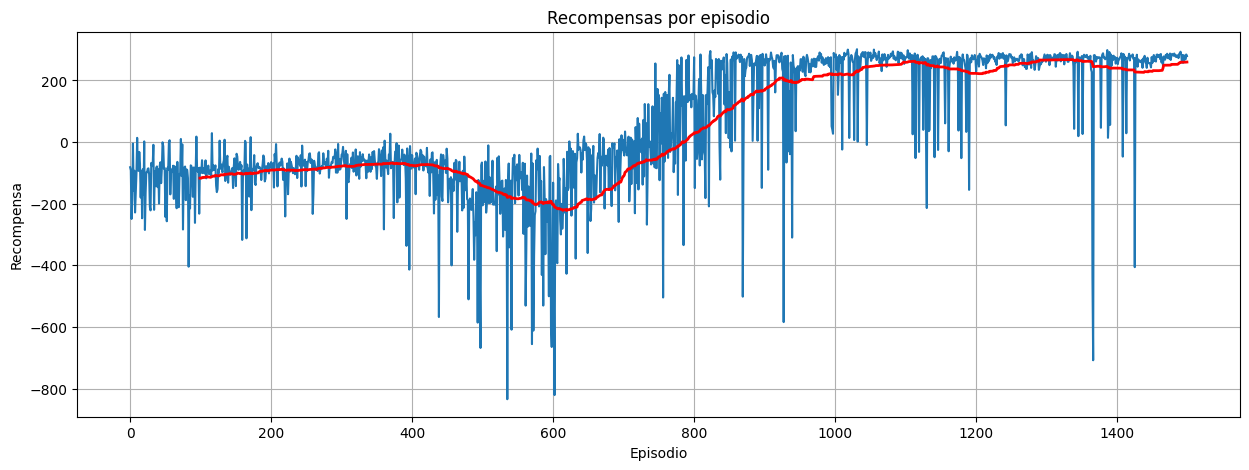

Máxima proporcion: 301.1870271119154


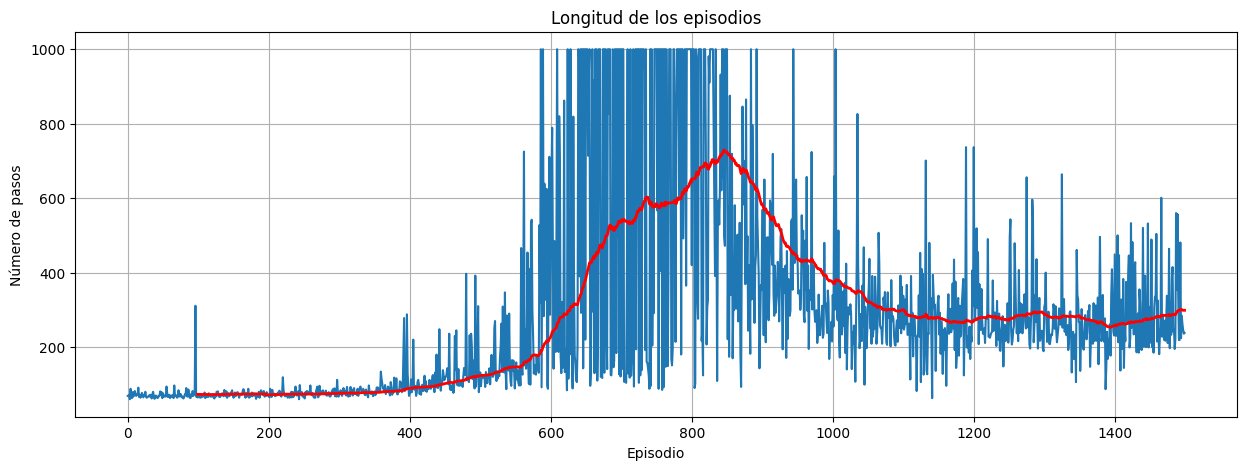

In [6]:
plot_stats(list_stats)
print(f"Máxima proporcion: {max(list_stats)}")
plot_episode_lengths(episode_lengths)

In [7]:
state, _ = env.reset(seed=seed)
ACTION_NAMES = {0: "DO_NOTHING", 1: "FIRE_MAIN_ENGINE", 2: "FIRE_LEFT_ENGINE", 3: "FIRE_RIGHT_ENGINE"}
actions_taken = []
frames = []
done = False
rewards = 0

while not done:
    frames.append(env.render())
    action = deep_q_learning_agent.get_action(state, training=False) # training False asegura np.argmax(self.q_values[state])
    actions_taken.append(ACTION_NAMES[action])
    state, reward, terminated, truncated, _ = env.step(action)
    rewards += reward
    done = terminated or truncated

print(f"Reward final:{rewards:.2f}")
print("Acciones:", " -> ".join(actions_taken))

Reward final:260.59
Acciones: FIRE_MAIN_ENGINE -> FIRE_MAIN_ENGINE -> FIRE_MAIN_ENGINE -> FIRE_MAIN_ENGINE -> FIRE_MAIN_ENGINE -> FIRE_MAIN_ENGINE -> FIRE_MAIN_ENGINE -> FIRE_MAIN_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_RIGHT_ENGINE -> DO_NOTHING -> FIRE_LEFT_ENGINE -> DO_NOTHING -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> DO_NOTHING -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> DO_NOTHING -> FIRE_LEFT_ENGINE -> DO_NOTHING -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_RIGHT_ENGINE -> DO_NOTHING -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> DO_NOTHING -> FIRE_LEFT_ENGINE -> DO_NOTHING -> FIRE_LEFT_ENGINE -> DO_NOTHING -> FIRE_LEFT_ENGINE -> FIRE_RIGHT_ENGINE -> DO_NOTHING -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> DO_NOTHING -> DO_NOTHING -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_RIGHT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> DO_NOTHING -> FIRE_LEFT_ENGINE -> FIRE

In [9]:
# Animación
fig, ax = plt.subplots()
ax.axis("off")
im = ax.imshow(frames[0])
def update(i):
    im.set_array(frames[i])
    return [im]
# blit = True para render más eficiente usando blitting -> https://es.wikipedia.org/wiki/Bit_blit
ani = animation.FuncAnimation(fig, update, frames=len(frames),interval=30, blit=True) 
plt.close(fig)  #  evita que se muestre la primera imagen estática
HTML(ani.to_jshtml())